In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import sys
sys.path.append('../../')
from src.bin_ligand_model import *
from src.ligand_coding_model import *


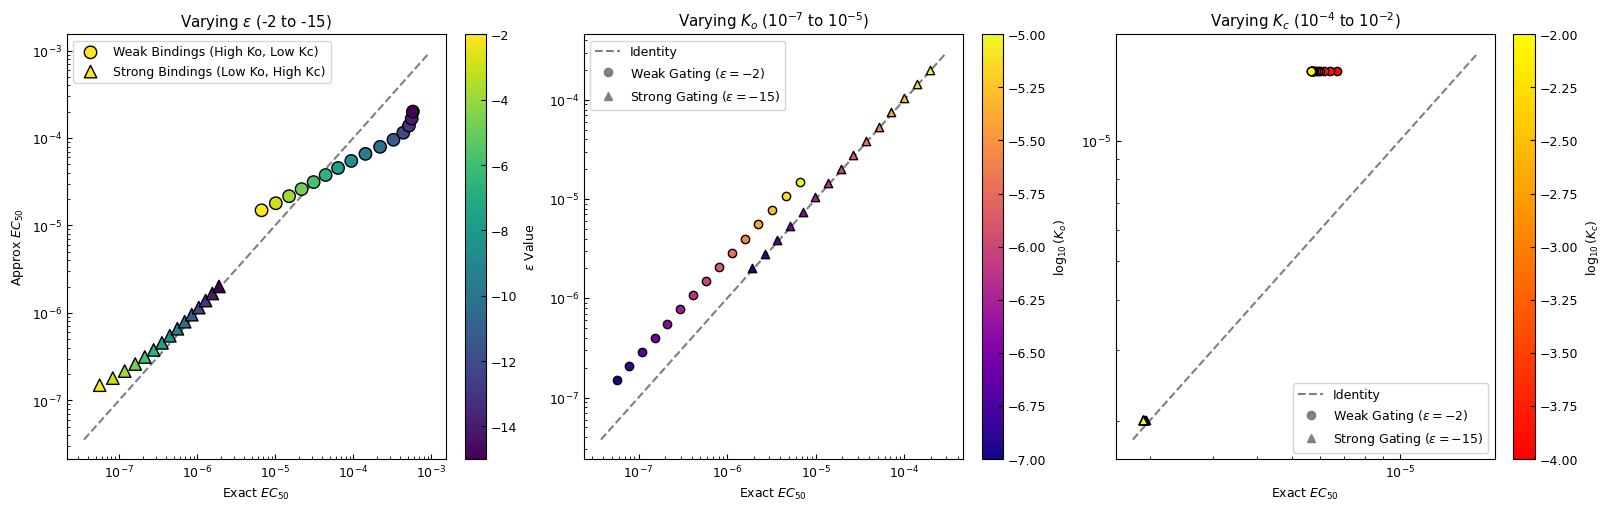

In [6]:
# --- 2. Setup Parameter Ranges ---
# Use log-spaced ranges as implied by your linspace of exponents
epss_log = np.linspace(-2, -15, 15)  # Epsilon from -2 to -15
Kos_log = np.linspace(-7, -5, 15)    # Ko from 1e-7 to 1e-5 (M)
Kcs_log = np.linspace(-4, -2, 15)    # Kc from 1e-4 to 1e-2 (M)

# Create real values
epss = epss_log
Kos_vals = 10**Kos_log
Kcs_vals = 10**Kcs_log

# Define Extremes for the "Fixed" parameters
eps_extremes = [epss[0], epss[-1]]   # Weakest (-2) and Strongest (-15)
Ko_extremes = [Kos_vals[0], Kos_vals[-1]] # Tightest (1e-7) and Weakest (1e-5)
Kc_extremes = [Kcs_vals[0], Kcs_vals[-1]] # Tightest (1e-4) and Weakest (1e-2)

# --- 3. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), constrained_layout=True)

# Helper to plot identity line
def add_identity(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0, label="Identity")

# === AX[0]: Vary Epsilon ===
# Fixed params: Ko and Kc extremes
ax = axes[0]
markers = ['o', '^'] # Circle for "bad" background, Triangle for "good" background
labels = ["Weak Bindings (High Ko, Low Kc)", "Strong Bindings (Low Ko, High Kc)"]

# Case 1: Worst case background (High Ko, Low Kc - small ratio)
Ko_fixed1 = np.full(5, Ko_extremes[1]) # Weakest Ko
Kc_fixed1 = np.full(5, Kc_extremes[0]) # Tightest Kc (closest to Ko)

# Case 2: Best case background (Low Ko, High Kc - big ratio)
Ko_fixed2 = np.full(5, Ko_extremes[0]) # Tightest Ko
Kc_fixed2 = np.full(5, Kc_extremes[1]) # Weakest Kc

for i, (Ko_fix, Kc_fix, mark, lbl) in enumerate(zip([Ko_fixed1, Ko_fixed2], [Kc_fixed1, Kc_fixed2], markers, labels)):
    exacts, approxs = [], []
    for eps in epss:
        ex = get_exact_ec50(eps, Ko_fix, Kc_fix)
        ap = EC50_approx(eps, Ko_fix)
        exacts.append(ex)
        approxs.append(ap)
    
    sc = ax.scatter(exacts, approxs, c=epss, cmap='viridis', marker=mark, edgecolor='k', s=80, label=lbl)

ax.set_title(r"Varying $\epsilon$ (-2 to -15)")
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("Exact $EC_{50}$"); ax.set_ylabel("Approx $EC_{50}$")
ax.legend()
add_identity(ax)
plt.colorbar(sc, ax=ax, label=r"$\epsilon$ Value")

# === AX[1]: Vary Ko ===
# Fixed params: Epsilon and Kc extremes
ax = axes[1]
# Case 1: Weakest Gating (eps=-2), Tightest Kc
eps_fix1 = eps_extremes[0]
Kc_fix1 = np.full(5, Kc_extremes[0])

# Case 2: Strongest Gating (eps=-15), Weakest Kc
eps_fix2 = eps_extremes[-1]
Kc_fix2 = np.full(5, Kc_extremes[-1])

for Ko_val in Kos_vals:
    # Homogeneous Ko for simplicity in this trend check
    Ko_in = np.full(5, Ko_val)
    
    # Plot Set 1
    ex1 = get_exact_ec50(eps_fix1, Ko_in, Kc_fix1)
    ap1 = EC50_approx(eps_fix1, Ko_in)
    ax.scatter(ex1, ap1, c=np.log10(Ko_val), cmap='plasma', vmin=min(Kos_log), vmax=max(Kos_log), marker='o', edgecolor='k')

    # Plot Set 2
    ex2 = get_exact_ec50(eps_fix2, Ko_in, Kc_fix2)
    ap2 = EC50_approx(eps_fix2, Ko_in)
    sc = ax.scatter(ex2, ap2, c=np.log10(Ko_val), cmap='plasma', vmin=min(Kos_log), vmax=max(Kos_log), marker='^', edgecolor='k')

ax.set_title(r"Varying $K_o$ ($10^{-7}$ to $10^{-5}$)")
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("Exact $EC_{50}$")
add_identity(ax)
# Manual legend
ax.plot([], [], 'o', color='gray', label=r"Weak Gating ($\epsilon=-2$)")
ax.plot([], [], '^', color='gray', label=r"Strong Gating ($\epsilon=-15$)")
ax.legend()
plt.colorbar(sc, ax=ax, label=r"$\log_{10}(K_o)$")

# === AX[2]: Vary Kc ===
# Fixed params: Epsilon and Ko extremes
ax = axes[2]
# Case 1: Weakest Gating, Weakest Ko
eps_fix1 = eps_extremes[0]
Ko_fix1 = np.full(5, Ko_extremes[1])

# Case 2: Strongest Gating, Tightest Ko
eps_fix2 = eps_extremes[-1]
Ko_fix2 = np.full(5, Ko_extremes[0])

for Kc_val in Kcs_vals:
    Kc_in = np.full(5, Kc_val)
    
    # Plot Set 1
    ex1 = get_exact_ec50(eps_fix1, Ko_fix1, Kc_in)
    ap1 = EC50_approx(eps_fix1, Ko_fix1)
    # Note: Approximation DOES NOT depend on Kc, so ap1 is constant for all Kc!
    # We color by Kc to show the drift of the EXACT value
    ax.scatter(ex1, ap1, c=np.log10(Kc_val), cmap='autumn', vmin=min(Kcs_log), vmax=max(Kcs_log), marker='o', edgecolor='k')

    # Plot Set 2
    ex2 = get_exact_ec50(eps_fix2, Ko_fix2, Kc_in)
    ap2 = EC50_approx(eps_fix2, Ko_fix2)
    sc = ax.scatter(ex2, ap2, c=np.log10(Kc_val), cmap='autumn', vmin=min(Kcs_log), vmax=max(Kcs_log), marker='^', edgecolor='k')

ax.set_title(r"Varying $K_c$ ($10^{-4}$ to $10^{-2}$)")
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("Exact $EC_{50}$")
add_identity(ax)
# Manual legend
ax.plot([], [], 'o', color='gray', label=r"Weak Gating ($\epsilon=-2$)")
ax.plot([], [], '^', color='gray', label=r"Strong Gating ($\epsilon=-15$)")
ax.legend()
plt.colorbar(sc, ax=ax, label=r"$\log_{10}(K_c)$")

plt.show()

In [ ]:
fig,ax = plt.subplot(ncols=3,figsize=(9,3))

epss = np.linspace(-2,-15,10)
Kos = np.linspace(-2,-5,10)
Kcs = np.linspace(-2,-5,10)

c12_eps = list()
c12_Kos = list()
c12_Kcs = list()

# first check the validity of epsilon
for eps in epss:    
    Ko_in1 = np.array([Kos[0] for _ in range(5)])
    Kc_in1 = np.array([Kcs[0] for _ in range(5)])
    Ko_in2 = np.array([Kos[-1] for _ in range(5)])
    Kc_in2 = np.array([Kcs[-1] for _ in range(5)])
    
    ec50_ex = get_exact_ec50(eps, Ko_in, Kc_in)
    ec50_ap = EC50_approx(eps, Ko_in)




# Case 1: "Good" Regime (Strong gating, distinct affinities)
eps_good = 
Kos_good = [1e-7, 5e-7, 1e-6, 2e-6, 5e-6] # Heterogeneous Kos around 1 uM
Kcs_good = [1e-4] * 5                   # Uniform Kc (100 uM)

# Case 2: "Bad" Regime (Weak gating)
eps_bad = -2
Kos_bad = Kos_good
Kcs_bad = Kcs_good

c_range = np.logspace(-10, -2, 100)

for eps, label, color in zip([eps_good, eps_bad], ["Valid Approx", "Invalid Approx"], ['green', 'red']):
    # Calculate Curves
    y = PoHeteroNorm(c_range, eps, Kos_good, Kcs_good)
    
    # Calculate EC50s
    ec50_ex = get_exact_ec50(eps, Kos_good, Kcs_good)
    ec50_ap = EC50_approx(eps, Kos_good)
    
    # Plot
    ax1.plot(c_range, y, label=f"{label} ($\epsilon={eps}$)", color=color, linewidth=2)
    ax1.axvline(ec50_ex, color=color, linestyle='-', alpha=0.5)
    ax1.axvline(ec50_ap, color=color, linestyle='--', alpha=0.5)
    
    # Add dots for EC50
    ax1.scatter(ec50_ex, 0.5, color=color, s=50, zorder=5)
    ax1.scatter(ec50_ap, 0.5, color=color, marker='x', s=50, zorder=5)

ax1.set_xscale('log')
ax1.set_xlabel('Ligand Concentration [M]')
ax1.set_ylabel('Normalized P_open')
ax1.set_title('A. Dose-Response Curves\n(Solid line/dot: Exact, Dashed/x: Approx)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

In [ ]:
# --- 4. Plotting & Analysis ---

# --- PANEL B: Systematic Error vs Epsilon ---
ax2 = fig.add_subplot(gs[0, 1])

eps_values = np.linspace(-30, 0, 50)
errors = []

for e in eps_values:
    exact = get_exact_ec50(e, Kos_good, Kcs_good)
    approx = EC50_approx(e, Kos_good)
    # Relative Error
    errors.append(approx / exact)

ax2.plot(eps_values, errors, color='purple', linewidth=2)
ax2.axhline(1.0, color='black', linestyle='--')
ax2.set_xlabel('Gating Energy $\epsilon$ ($k_BT$)')
ax2.set_ylabel('Ratio Approx / Exact')
ax2.set_title('B. Validity Range\n(Approximation assumes $1 \ll e^{-\epsilon}$)')
ax2.grid(True, alpha=0.3)
ax2.text(-25, 1.1, "Good Fit", color='green', fontweight='bold')
ax2.text(-5, 1.3, "Fail", color='red', fontweight='bold')

# --- PANEL C: Scatter Plot (Random Parameters) ---
ax3 = fig.add_subplot(gs[0, 2])

np.random.seed(42)
num_samples = 200
exacts = []
approxs = []
colors = []

for _ in range(num_samples):
    # Randomize parameters
    e_rand = np.random.uniform(-25, -5) # Random energy between -25 and -5
    
    # Generate 5 random Ko values between 1nM and 1uM (log uniform)
    #Kos_rand = 10**np.random.uniform(-9, -6, 5)
    Kos_rand = 5*[10**np.random.uniform(-9,-6)]
    
    # Kc is generally weaker (larger) than Ko. Set Kc between 10uM and 1mM
    Kcs_rand = 10**np.random.uniform(-5, -3, 5)
    
    ex = get_exact_ec50(e_rand, Kos_rand, Kcs_rand)
    ap = EC50_approx(e_rand, Kos_rand)
    
    exacts.append(ex)
    approxs.append(ap)
    #colors.append(e_rand) # Color by energy
    colors.append(np.mean(Kos_rand))

sc = ax3.scatter(exacts, approxs, c=colors, cmap='viridis', alpha=0.7)
ax3.plot([1e-9, 1e-4], [1e-9, 1e-4], 'k--', label='Perfect match')

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('Exact EC50 [M]')
ax3.set_ylabel('Approx EC50 [M]')
ax3.set_title('C. Heterogeneity Test\n(Color = $\epsilon$)')
plt.colorbar(sc, ax=ax3, label='Energy $\epsilon$')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()